In [433]:
import pandas as pd
import numpy as np
import re
import sys
from pathlib import Path

# Get the path to the current script
current_dir = Path.cwd()

# Go one level up
current_dir = current_dir.parent

# Add the 'scripts' directory to sys.path to be able to import data_utils.py
sys.path.append(str(current_dir))

from scripts.data_utils import split_summary_methods, format_mean_std
import ast  
import matplotlib.pyplot as plt
import seaborn as sns
from autorank import autorank, plot_stats, create_report

pd.set_option('display.max_colwidth', None)

In [434]:
MAX_NUMBER_OF_RUNS_STOCASTIC = 3

TYPE_WS = "params_with_p_window_size" #params_with_p_window_size or params_with_window


#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pds_and_pv_bv3_bv4_bv5.xlsx")
data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pv_bv5_for_fplasma_fcurrent_pv.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_and_own_method_eval_pv_bv5_with_current_gtv2_ds.xlsx")
#data = pd.read_excel(current_dir / "datasets" / "summaries" / "summary_results_sota_mgragstream_and_own_method_eval_public_ds.xlsx")

# Reading PV dataset showing all hyperparameters considered
#order_pv = ['A1', 'A2', 'A3', 'A4', 'A5', 'A6', 'A7', 'A8', 'A9','SA1', 'SA2', 'SA3','DA1', 'DA2', 'DA3','TA1', 'TA2', 'TA3']

# Reading Public dataset showing all hyperparameters considered
#order_pds = ['551', '171', '115', '137', '116']

#concatenated_order = order_pv + order_pds

#data = pd.concat([data_sota_pv, data_sota_pds])
#data = data_sota_eval_pds
data['cod_scenario'] = data['cod_scenario'].astype(str)
#data['scenario'] = pd.Categorical(data['scenario'], categories=concatenated_order, ordered=True)

data['method_window_and_param'] = data['method_window_and_param'].str.replace("SWKNN_own", "SWKNN(own)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case1", "pmDragStream(Case1)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case2", "pmDragStream(Case2)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case3", "pmDragStream(Case3)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("point_mDragStream_case4", "pmDragStream(Case4)")

data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case1", "smDragStream(Case1)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case2", "smDragStream(Case2)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case3", "smDragStream(Case3)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("subsequence_mDragStream_case4", "smDragStream(Case4)")

data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TNone", "OBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("OnlineBootKNN_TZnorm", "OBKNN (TZNorm)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TNone", "SFOBKNN (TNone)")
data['method_window_and_param'] = data['method_window_and_param'].str.replace("SFOnlineBootKNN_TZnorm", "SFOBKNN (TZNorm)")


data['code_and_name_scenario'] = data['cod_scenario'] +"_"+ data['name_scenario'].astype(str)

data.method_window_and_param.unique()



array(["OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",
       "OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",
       "xStream_84_{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",
       "RSHash_840_{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",
       "IForestASD_840_{'initial_window_X': None, 'p_wi

In [435]:
data.columns

Index(['iteration', 'cod_scenario', 'name_scenario', 'method_window_and_param',
       'p_window_size', 'window_size', 'raw_roc_auc', 'raw_pr_auc',
       'raw_max_f1', 'raw_roc_auc_wtd', 'raw_pr_auc_wtd', 'raw_max_f1_wtd',
       'raw_pct_detection', 'raw_pct_false_positives', 'tn', 'fp', 'fn', 'tp',
       'best_threshold', 'auc_roc', 'auc_pr', 'precision', 'f_metric',
       'precision_at_k', 'rprecision', 'rrecall', 'rf', 'r_auc_roc',
       'r_auc_pr', 'vus_roc', 'vus_pr', 'affiliation_precision',
       'affiliation_recall', 'mean_training_time', 'max_training_time',
       'min_training_time', 'mean_scoring_time', 'max_scoring_time',
       'min_scoring_time', 'count_cleaned_score', 'count_raw_score',
       'count_anomalies', 'count_normal', 'code_and_name_scenario'],
      dtype='object')

In [436]:
# Find duplicates for the same iteration and the same experiment
duplicates = data[["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].duplicated(keep=False)
data[duplicates][["iteration", "cod_scenario", "method_window_and_param", "count_cleaned_score"]].sort_values(by=["method_window_and_param"])

,iteration,cod_scenario,method_window_and_param,count_cleaned_score


In [437]:
# Adjusting format and creating new columns for analysis in the dataset read

# Extracting new columns for the method, window_size, parameters
data[['method',"window_size", 'parameters']] = data['method_window_and_param'].apply(
    lambda x: pd.Series(split_summary_methods(x))
)

# Creating new column params_with_window
data["params_with_p_window_size"] = data["parameters"]
data["params_with_p_window_size"] = data["params_with_p_window_size"].str.replace("}_{", ",", regex=False)

data["params_with_window"] = "{'window_size': " + data["window_size"].astype(str)+data["parameters"].str.replace("{", ", ", regex=False)
data["params_with_window"] = data["params_with_window"].str.replace("}_{", ",", regex=False)

# Define your list of non-stochastic methods
non_stochastic_methods = ["SWKNN", "SWKNN_own", "SWLOF", "KitNet", "ExactStorm", "mDragStream","SFSWKNN", "SFSWKNN_own", "SFSWLOF", "SFKitNet", "SFExactStorm", "SFmDragStream"]

# Create the 'stochastic' column
data['stochastic'] = data['method'].apply(
    lambda x: 'N' if x in non_stochastic_methods else 'Y')


# Create the 'public' dataset column
data['public'] = np.where(data['cod_scenario'].str.isdigit(), 'Y', 'N')

# Shortening the name of the methods
new_method_name = {"xStream":"XStream", 
"RSHash":"RSHash", "IForestASD":"IFASD", "RobustRandomCutForest":"RRCF", "KitNet":"KitNet", "ExactStorm":"EStorm","oIF":"OIF", "HStree":"HStree", "OnlineBootKNN":"OBKNN",
"SFxStream":"SFXStream", 
"SFRSHash":"SFRSHash", "SFIForestASD":"SFIFASD", "SFRobustRandomCutForest":"SFRRCF", "SFKitNet":"SFKitNet", "SFExactStorm":"SFEStorm","SFoIF":"SFOIF", "SFHStree":"SFHStree", "SFOnlineBootKNN":"SFOBKNN"
} 

data["method"] = data['method'].replace(new_method_name)
data["method_with_param"] = data['method']+"_"+data["parameters"]

# Flag for mDrastream
is_drag = data['method'].isin(['mDragStream'])
is_drag1 = data['method'].isin(['pmDragStream(Case1)'])
is_drag2 = data['method'].isin(['pmDragStream(Case2)'])
is_drag3 = data['method'].isin(['pmDragStream(Case3)'])
is_drag4 = data['method'].isin(['pmDragStream(Case4)'])

is_sdrag1 = data['method'].isin(['smDragStream(Case1)'])
is_sdrag2 = data['method'].isin(['smDragStream(Case2)'])
is_sdrag3 = data['method'].isin(['smDragStream(Case3)'])
is_sdrag4 = data['method'].isin(['smDragStream(Case4)'])


is_euc = data['params_with_window'].str.contains('euclidean', case=False, na=False)
is_mah = data['params_with_window'].str.contains('mahalanobis', case=False, na=False)

data['method'] = np.select(
    [is_drag & is_euc, is_drag & is_mah, is_drag1 & is_euc, is_drag1 & is_mah,is_drag2 & is_euc, is_drag2 & is_mah, is_drag3 & is_euc, is_drag3 & is_mah, is_drag4 & is_euc, is_drag4 & is_mah], 
    ['mDragStream (Euc)', 'mDragStream (Mah)','mDragStream Case 1 (Euc)', 'mDragStream Case 1 (Mah)','mDragStream Case 2 (Euc)', 'mDragStream Case 2 (Mah)','mDragStream Case 3 (Euc)', 'mDragStream Case 3 (Mah)','mDragStream Case 4 (Euc)', 'mDragStream Case 4 (Mah)'], 
    default=data['method']
)

data['method'] = np.select(
    [is_sdrag1 & is_euc, is_sdrag1 & is_mah,is_sdrag2 & is_euc, is_sdrag2 & is_mah, is_sdrag3 & is_euc, is_sdrag3 & is_mah, is_sdrag4 & is_euc, is_sdrag4 & is_mah], 
    ['subsequencemDragStream Case 1 (Euc)', 'subsequencemDragStream Case 1 (Mah)','subsequencemDragStream Case 2 (Euc)', 'subsequencemDragStream Case 2 (Mah)','subsequencemDragStream Case 3 (Euc)', 'subsequencemDragStream Case 3 (Mah)','subsequencemDragStream Case 4 (Euc)', 'subsequencemDragStream Case 4 (Mah)'], 
    default=data['method']
)

#Separating OnlineBootKNN with None, Z-normalization or SQRT transformation
# Case 1: None
mask_none = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('NONE', case=False, na=False))
data.loc[mask_none, 'method'] = 'OBKNN (None)'

# Case 2: ZNormalization
mask_znorm = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('ZNORM', case=False, na=False))
data.loc[mask_znorm, 'method'] = 'OBKNN (ZNorm)'

# Case 2: ZNormalization
mask_sqrt = (data['method'] == 'OBKNN') & \
           (data['params_with_window'].str.contains('SQRT', case=False, na=False))
data.loc[mask_sqrt, 'method'] = 'OBKNN (TSqrt)'

# Including the year of publication of the methods
method_and_year = {
"XStream":"2018", 
"RSHash":"2011", "IFASD":"2013", "RRCF":"2016", "KitNet":"2018", "EStorm":"2007","OIF":"2024", "HStree":"2011", 
"OBKNN (TNone)":"2025", "OBKNN (TZNorm)":"2025", "BKNN":"2025", "SWKNN":"2000","SWLOF":"2000", 
"SWKNN_own":"2025", "mDragStream (Mah)":"2025", "mDragStream (Euc)":"2025",
"SFXStream":"2018", 
"SFRSHash":"2011", "SFIFASD":"2013", "SFRRCF":"2016", "SFKitNet":"2018", "SFEStorm":"2007","SFOIF":"2024", "SFHStree":"2011", 
"SFOBKNN (TNone)":"2025", "SFOBKNN (TZNorm)":"2025", "SFBKNN":"2025", "SFSWKNN":"2000","SFSWLOF":"2000", 
"SFSWKNN_own":"2025", "SFmDragStream (Mah)":"2025", "SFmDragStream (Euc)":"2025",

} 
data["method_and_year"] = data['method'].map(lambda x: f"{x} ({method_and_year.get(x, 'Unknown')})")



In [438]:
# Obtaining the best hyperparameters (for all window sizes)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'parameters', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','parameters']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()


#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best hyperparameters (for all window sizes)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_params = best_results['parameters'].unique().tolist()
#best_results


In [439]:
# Obtaining the best window size (for all hyperparameters)
# 1. average results over all iterations and all scenarios
averaged_results = data.groupby(['method', 'p_window_size', 'cod_scenario'])['raw_pr_auc'].agg(
    mean_auc_pr='mean',
    std_auc_pr='std',
    n_runs='count'
).reset_index()
# 2. average results for each method and hyperparameter (including window size) for all scenarios
summary = averaged_results.groupby(['method','p_window_size']).agg(
    mean_auc_pr=('mean_auc_pr', 'mean'),
    std_auc_pr=('std_auc_pr', 'mean'),
    n_scenarios=('mean_auc_pr', 'count'),
    #n_experiments=('n_runs', 'sum')
).reset_index()

#summary.sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True]).head(10)

# Obtaining the best window size (for all hyperparameters)
# 3. Select the highest AUC_PR per method and hyperparameter
best_results = (
    summary
    .sort_values(['mean_auc_pr','std_auc_pr'], ascending=[False, True])
    .groupby('method')
    .head(1)
)
#best_ws = best_results[TYPE_WINDOW_SIZE].unique().tolist()
#best_results 

In [440]:
# Obtaining the hyperparameters that are complete for analysis
averaged_results = data.groupby(['method', 'stochastic', TYPE_WS, 'cod_scenario'])['raw_pr_auc'].agg(
    n_runs='count',
).reset_index()

# Condition 1: Stochastic methods must have MAX_NUMBER_OF_RUNS_STOCASTIC
cond_stochastic = (averaged_results['n_runs'] == MAX_NUMBER_OF_RUNS_STOCASTIC) & (averaged_results['stochastic'] == 'Y')

# Condition 2: Non-Stochastic methods must have 3 run (different from tuning in order to asssess computation time)
cond_non_stochastic = (averaged_results['n_runs'] == 3) & (averaged_results['stochastic'] == 'N')

# Apply the combined filter using | (OR)
# Let's call this new variable 'filtered_results'
filtered_results = averaged_results[cond_stochastic | cond_non_stochastic]

# Now, 'filtered_results' contains the data you wanted to see
# You can uncomment the next line to inspect it:
# print("--- Filtered Results (Step 1) ---")
# display(filtered_results)



In [441]:
data['method_window_and_param'].unique()

array(["OBKNN (TNone)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'NONE', 'type_dist': 'largest', 'update_distance_with_abnormal': False, 'update_mode_stats': 'ema'}",
       "OBKNN (TZNorm)_840_{'algorithm': 'brute', 'alpha_ema': 0.01, 'alpha_z_test': 0.05, 'chunk_size': 30, 'dmetric': 'cityblock', 'ensemble_size': 30, 'n_jobs': -1, 'no_bootstrapp': False, 'no_z_score': False, 'p_window_size': 0.2, 'transf': 'ZNORM', 'type_dist': 'largest', 'update_distance_with_abnormal': True, 'update_mode_stats': 'welford'}",
       "xStream_84_{'depth': 25, 'n_chains': 100, 'num_components': 50, 'p_window_size': 0.02}",
       "RSHash_840_{'decay': 0.05, 'feature_maxes': [inf, 2000], 'feature_mins': [0], 'num_components': 50, 'num_hash_fns': 1, 'p_window_size': 0.2}",
       "IForestASD_840_{'initial_window_X': None, 'p_wi

## Summary Score of Online Anomaly Detectors with PV Datasets for currenat and features of Plasma (electrical current, voltage and pressure) in degasying cycles

In [442]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
filtered_data = filtered_data[filtered_data['public'] == 'N']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features

filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNHFP","HARFP","LNHFP","LARFP","RNHFP","RARFP","RMXFP","HNHOC","HAROC","LNHOC","LAROC","RNHOC","RAROC","RMXOC"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [443]:
print("Number of Datasets:", str(len(filtered_data.cod_scenario.unique())))
print("Datasets:", str(filtered_data.cod_scenario.unique()))
print("Number of Methods:", str(len(filtered_data.method_window_and_param.unique())))

Number of Datasets: 14
Datasets: ['HARFP' 'HAROC' 'HNHFP' 'HNHOC' 'LARFP' 'LAROC' 'LNHFP' 'LNHOC' 'RARFP'
 'RAROC' 'RMXFP' 'RMXOC' 'RNHFP' 'RNHOC']
Number of Methods: 11


In [444]:
df = filtered_data.copy()

df['is_oc'] = df['code_and_name_scenario'].str.endswith('OC')
df['feature_set'] = df['is_oc'].map({True: 'Only Current', False: 'Plasma Features'})

mean_df = df.pivot_table(index='method', columns='feature_set', values='vus_pr', aggfunc='mean')
std_df = df.pivot_table(index='method', columns='feature_set', values='vus_pr', aggfunc='std')

for col in ['Only Current', 'Plasma Features']:
    if col not in mean_df.columns:
        mean_df[col] = float('nan')
        std_df[col] = float('nan')

final_table = pd.DataFrame(index=mean_df.index)

for col in ['Only Current', 'Plasma Features']:
    final_table[col] = mean_df.apply(
        lambda row, c=col: format_mean_std(row[c], std_df.loc[row.name, c]) if pd.notna(row[c]) else '-', 
        axis=1
    )

final_table = final_table[['Only Current', 'Plasma Features']]
final_table.index.name = 'Method'
final_table.columns.name = None

final_table

,Only Current,Plasma Features
Method,,
EStorm,0.039 ± 3.5e-02,0.041 ± 3.4e-02
HStree,0.032 ± 2.9e-02,0.032 ± 2.8e-02
IFASD,0.083 ± 2.2e-02,0.098 ± 2.6e-02
KitNet,-,0.117 ± 2.7e-02
OBKNN (TNone),0.093 ± 2.7e-02,0.084 ± 2.0e-02
OBKNN (TZNorm),-,0.131 ± 7.6e-02
OIF,0.076 ± 2.5e-02,0.084 ± 2.5e-02
RRCF,0.063 ± 2.4e-02,0.065 ± 2.3e-02
RSHash,0.073 ± 2.1e-02,0.090 ± 1.9e-02


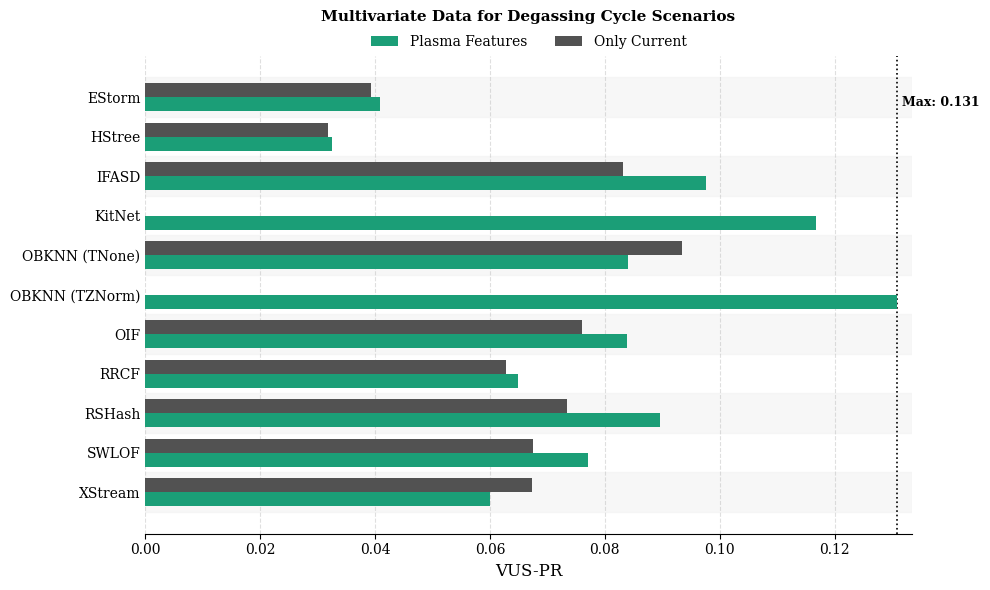

In [445]:

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "text.usetex": False
})

df = filtered_data.copy()

df["is_oc"] = df["code_and_name_scenario"].str.endswith("OC")
df["feature_set"] = df["is_oc"].map({
    True: "Only Current",
    False: "Plasma Features"
})

mean_df = df.pivot_table(
    index="method",
    columns="feature_set",
    values="vus_pr",
    aggfunc="mean"
)

for col in ["Only Current", "Plasma Features"]:
    if col not in mean_df.columns:
        mean_df[col] = np.nan

# Alphabetical ordering
mean_df.index = mean_df.index.str.strip()
ranking = sorted(mean_df.index, key=str.lower)

means_pf = mean_df.loc[ranking, "Plasma Features"]
means_oc = mean_df.loc[ranking, "Only Current"]

y = np.arange(len(ranking))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(ranking)):
    if i % 2 == 0:
        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="#f0f0f0",
            alpha=0.5,
            zorder=0
        )

ax.barh(
    y + height / 2,
    means_pf,
    height,
    color="#1b9e77",
    label="Plasma Features",
    zorder=3
)

ax.barh(
    y - height / 2,
    means_oc,
    height,
    color="#525252",
    label="Only Current",
    zorder=3
)

max_x = max(means_pf.max(), means_oc.max())

# Small margin only
plot_limit = max_x * 1.02

ax.axvline(
    x=max_x,
    color="black",
    linestyle=":",
    linewidth=1.2,
    zorder=2
)

ax.text(
    max_x + 0.001,
    0.3,
    f"Max: {max_x:.3f}",
    va="bottom",
    ha="left",
    fontsize=9,
    fontweight="bold",
    color="black"
)

ax.set_yticks(y)
ax.set_yticklabels(ranking)

# Display alphabetically from top to bottom
ax.invert_yaxis()

ax.set_xlim(0, plot_limit)

ax.set_xlabel("VUS-PR")

ax.set_title(
    "Multivariate Data for Degassing Cycle Scenarios",
    fontweight="bold",
    fontsize=11,
    pad=25
)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_bounds(0, plot_limit)

ax.tick_params(axis="y", length=0)

# Let matplotlib choose ticks automatically
plt.tight_layout()

plt.savefig(
    "img_sf_only_spectra_multi/results_plot_multivariate_degassing_scenarios.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()

## Summary Score of Online Anomaly Detectors with PV Datasets for currenat and features of Plasma (electrical current, voltage and pressure) Other Scenarios

In [446]:
#Applying filters to analyse data

#regex_filter = "|".join(["'transf': 'None'", "shingle_size",'SWKNN'])
regex_filter = "|".join([""])

filtered_data = data[data['method_window_and_param'].str.contains(regex_filter, regex=True)]
filtered_data = filtered_data[filtered_data['public'] == 'N']

# Filter rows where 'parameters' column contains any of the best_params
#filtered_data = filtered_data[filtered_data['params_with_window'].isin(best_params)]


#filtered_data = filtered_data[filtered_data['method'].str.contains("std_p")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("None|FOD|SOD|DIL|QUANT")]
#filtered_data = filtered_data[filtered_data['method'].str.contains("QUANT")]
#filtered_data = filtered_data[filtered_data.method.str.contains("OnlineBootGP|OnlineBootKNN")]

# Now, sort the data based on the 'scenario' column
filtered_data = filtered_data.sort_values(by='cod_scenario')

#filtered_data = filtered_data[~filtered_data.window_size.isin(["60"])]

#filtered_data = filtered_data[filtered_data.method.isin(["ExactStorm", "OnlineBootKNN"])]
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["A10","A11","A12"])]# excluded since no detector performs well in these datasets 
#filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["118","119","120","121","122","123","124","125","126","127","128", "172"])]# excluded since just one dataset of TAO is used (117) for fair comparison among benchmarks
filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["019","079","084"])]# excluded since there is no results for OBKNN (ZNORM) because of very small number of features

filtered_data = filtered_data[~filtered_data.cod_scenario.isin(["HNHFP","HARFP","LNHFP","LARFP","RNHFP","RARFP","RMXFP","HNHOC","HAROC","LNHOC","LAROC","RNHOC","RAROC","RMXOC"])]

#filtered_data = filtered_data[filtered_data.scenario.isin(["A1", "A2","A3","A4", "A5","A6","A7", "A8","A9"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["DA2","137"])] 
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["HNH","HAR","LNH","LAR"])] 
#filtered_data = filtered_data[filtered_data.scenario.isin(["TA1", "TA2","TA3", "DA3"])]
#filtered_data = filtered_data[~filtered_data.scenario.isin(["SWaT","PSM","CreditCard","172"])]
#filtered_data = filtered_data[filtered_data.cod_scenario.isin(["RMX"])]


#filtered_data = filtered_data[filtered_data['method_window_and_param'].isin(PARAMS)]
#filtered_data = filtered_data[filtered_data[TYPE_WS].isin(hyperparameters_complete)]

#total_scenarios = len(filtered_data.scenario.unique())
# Compute overall mean, std, and count across all datasets
# Exclude the rows where the number of scenarios is not equal to total_scenarios
#summary = summary[summary.n_scenarios==total_scenarios]

#filtered_data.head(10)
#filtered_data.to_excel("/home/nicolas/spectral_anomaly_detector/datasets/summaries/summary_results_sota_and_dragstream_method_eval_pds.xlsx")

In [447]:
print("Number of Datasets:", str(len(filtered_data.cod_scenario.unique())))
print("Datasets:", str(filtered_data.cod_scenario.unique()))
print("Number of Methods:", str(len(filtered_data.method_window_and_param.unique())))

Number of Datasets: 10
Datasets: ['SAR1FP' 'SAR1OC' 'SAR2FP' 'SAR2OC' 'SAR3FP' 'SAR3OC' 'TARFP' 'TAROC'
 'TNHFP' 'TNHOC']
Number of Methods: 11


In [448]:
df = filtered_data.copy()

df['is_oc'] = df['code_and_name_scenario'].str.endswith('OC')
df['feature_set'] = df['is_oc'].map({True: 'Only Current', False: 'Plasma Features'})

mean_df = df.pivot_table(index='method', columns='feature_set', values='vus_pr', aggfunc='mean')
std_df = df.pivot_table(index='method', columns='feature_set', values='vus_pr', aggfunc='std')

for col in ['Only Current', 'Plasma Features']:
    if col not in mean_df.columns:
        mean_df[col] = float('nan')
        std_df[col] = float('nan')

final_table = pd.DataFrame(index=mean_df.index)

for col in ['Only Current', 'Plasma Features']:
    final_table[col] = mean_df.apply(
        lambda row, c=col: format_mean_std(row[c], std_df.loc[row.name, c]) if pd.notna(row[c]) else '-', 
        axis=1
    )

final_table = final_table[['Only Current', 'Plasma Features']]
final_table.index.name = 'Method'
final_table.columns.name = None

final_table

,Only Current,Plasma Features
Method,,
EStorm,0.158 ± 8.0e-02,0.123 ± 6.5e-02
HStree,0.245 ± 2.6e-01,0.118 ± 8.1e-02
IFASD,0.607 ± 3.5e-01,0.473 ± 2.8e-01
KitNet,-,0.650 ± 4.2e-01
OBKNN (TNone),0.646 ± 4.5e-01,0.635 ± 4.0e-01
OBKNN (TZNorm),-,0.612 ± 3.4e-01
OIF,0.252 ± 1.5e-01,0.354 ± 3.3e-01
RRCF,0.160 ± 5.1e-02,0.238 ± 5.0e-02
RSHash,0.533 ± 1.8e-01,0.217 ± 6.5e-02


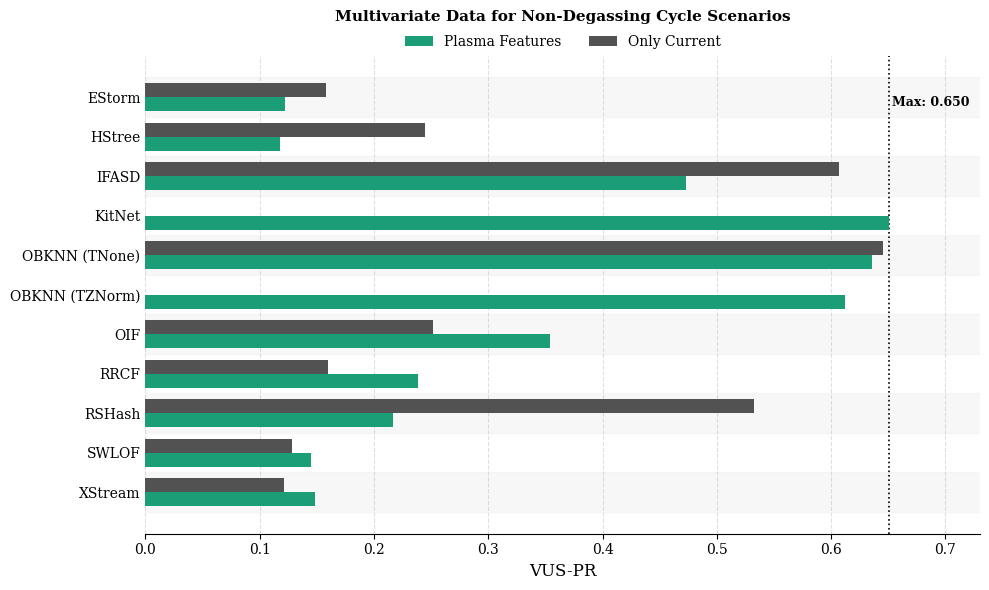

In [449]:

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 10,
    "axes.labelsize": 12,
    "xtick.labelsize": 10,
    "ytick.labelsize": 10,
    "legend.fontsize": 10,
    "text.usetex": False
})

df = filtered_data.copy()
df['is_oc'] = df['code_and_name_scenario'].str.endswith('OC')
df['feature_set'] = df['is_oc'].map({
    True: 'Only Current',
    False: 'Plasma Features'
})

mean_df = df.pivot_table(
    index='method',
    columns='feature_set',
    values='vus_pr',
    aggfunc='mean'
)

for col in ['Only Current', 'Plasma Features']:
    if col not in mean_df.columns:
        mean_df[col] = np.nan

# Alphabetical sorting
mean_df.index = mean_df.index.str.strip()
ranking = sorted(mean_df.index, key=str.lower)

means_pf = mean_df.loc[ranking, "Plasma Features"]
means_oc = mean_df.loc[ranking, "Only Current"]

y = np.arange(len(ranking))
height = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

for i in range(len(ranking)):
    if i % 2 == 0:
        ax.axhspan(
            i - 0.5,
            i + 0.5,
            color="#f0f0f0",
            alpha=0.5,
            zorder=0
        )

bars_pf = ax.barh(
    y + height / 2,
    means_pf,
    height,
    color="#1b9e77",
    label="Plasma Features",
    zorder=3
)

bars_oc = ax.barh(
    y - height / 2,
    means_oc,
    height,
    color="#525252",
    label="Only Current",
    zorder=3
)

max_x = max(means_pf.max(), means_oc.max())
plot_limit = max_x + 0.08

ax.axvline(
    x=max_x,
    color="black",
    linestyle=":",
    linewidth=1.2,
    zorder=2
)

ax.text(
    max_x + 0.003,
    0.3,
    f"Max: {max_x:.3f}",
    va="bottom",
    ha="left",
    fontsize=9,
    fontweight="bold",
    color="black"
)

ytick_labels = []
for method in ranking:
    if pd.isna(means_pf[method]) or pd.isna(means_oc[method]):
        ytick_labels.append(method)
    else:
        ytick_labels.append(method)

ax.set_yticks(y)
ax.set_yticklabels(ytick_labels)

# Alphabetical order from top to bottom
ax.invert_yaxis()

ax.set_xlim(0, plot_limit)

ax.set_xlabel("VUS-PR")

ax.set_title(
    "Multivariate Data for Non-Degassing Cycle Scenarios",
    fontweight="bold",
    fontsize=11,
    pad=25
)

ax.legend(
    frameon=False,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.07),
    ncol=2
)

ax.grid(
    axis="x",
    linestyle="--",
    alpha=0.4,
    zorder=1
)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_visible(False)
ax.spines["bottom"].set_bounds(0, plot_limit)

ax.tick_params(axis="y", length=0)

ticks = ax.get_xticks()
ax.set_xticks([t for t in ticks if t <= plot_limit])

plt.tight_layout()

plt.savefig(
    "img_sf_only_spectra_multi/results_plot_multivariate_non_degassing_scenarios.pdf",
    format="pdf",
    bbox_inches="tight"
)

plt.show()